In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pathlib

test_data = pathlib.Path('Combined Dataset/test/')
train_data = pathlib.Path('Combined Dataset/train/')

# 학습 클래스 및 이미지 개수 확인
train_classes = sorted([item.name for item in train_data.glob('*/') if item.is_dir()])
train_image_count = len(list(train_data.glob('*/*.jpg'))) # 모든 이미지
train_No_image_count = len(list(train_data.glob('No Impairment/*.jpg'))) # 없음
train_Very_Mild_image_count = len(list(train_data.glob('Very Mild Impairment/*.jpg'))) # 매우 경미함
train_Mild_image_count = len(list(train_data.glob('Mild Impairment/*.jpg'))) # 경미함
train_Moderate_image_count = len(list(train_data.glob('Moderate Impairment/*.jpg'))) # 중간정도
print(f"발견된 클래스: {train_classes}")
print(f"총 이미지 개수: {train_image_count}")
print(f"손상 없는 이미지 개수: {train_No_image_count}")
print(f"매우 경미한 손상의 뇌 이미지 개수: {train_Very_Mild_image_count}")
print(f"경미한 손상의 뇌 이미지 개수: {train_Mild_image_count}")
print(f"중간정도의 손상 이미지 개수: {train_Moderate_image_count}")

# 평가 클래스 및 이미지 개수 확인
test_classes = sorted([item.name for item in test_data.glob('*/') if item.is_dir()])
test_image_count = len(list(test_data.glob('*/*.jpg'))) # 모든 이미지
test_No_image_count = len(list(test_data.glob('No Impairment/*.jpg'))) # 없음
test_Very_Mild_image_count = len(list(test_data.glob('Very Mild Impairment/*.jpg'))) # 매우 경미함
test_Mild_image_count = len(list(test_data.glob('Mild Impairment/*.jpg'))) # 경미함
test_Moderate_image_count = len(list(test_data.glob('Moderate Impairment/*.jpg'))) # 중간정도
print(f"발견된 클래스: {test_classes}")
print(f"총 이미지 개수: {test_image_count}")
print(f"손상 없는 이미지 개수: {test_No_image_count}")
print(f"매우 경미한 손상의 뇌 이미지 개수: {test_Very_Mild_image_count}")
print(f"경미한 손상의 뇌 이미지 개수: {test_Mild_image_count}")
print(f"중간정도의 손상 이미지 개수: {test_Moderate_image_count}")

발견된 클래스: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
총 이미지 개수: 10240
손상 없는 이미지 개수: 2560
매우 경미한 손상의 뇌 이미지 개수: 2560
경미한 손상의 뇌 이미지 개수: 2560
중간정도의 손상 이미지 개수: 2560
발견된 클래스: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
총 이미지 개수: 1279
손상 없는 이미지 개수: 640
매우 경미한 손상의 뇌 이미지 개수: 448
경미한 손상의 뇌 이미지 개수: 179
중간정도의 손상 이미지 개수: 12


Found 10240 files belonging to 4 classes.
Found 1279 files belonging to 4 classes.
클래스: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


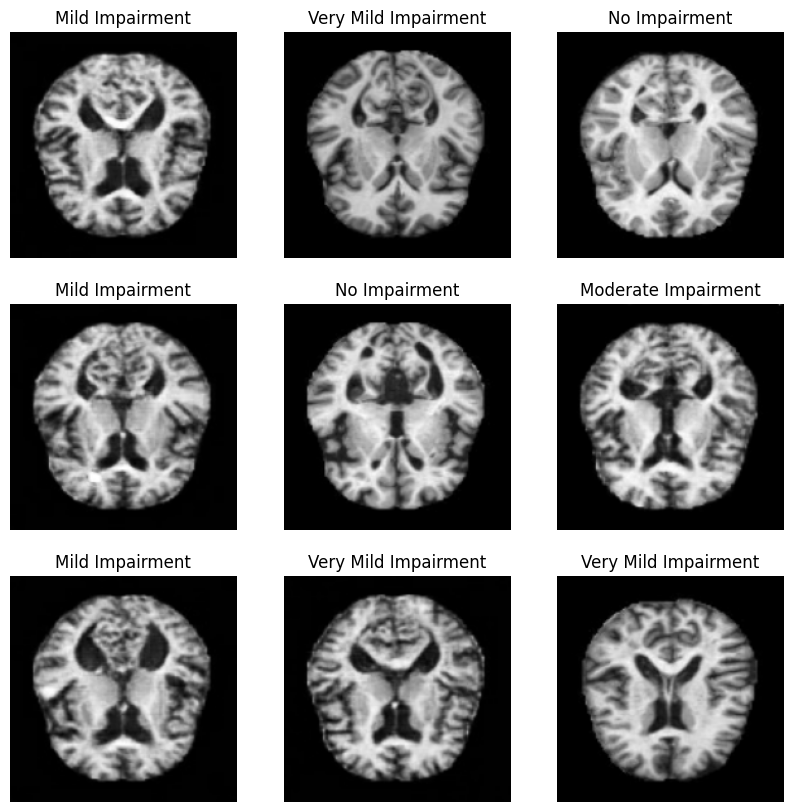

In [3]:
# 이미지 크기 및 배치 크기 설정
img_height = 180
img_width = 180
batch_size = 32
epochs = 100

# 훈련 데이터셋 생성
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(train_data),
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 검증 데이터셋 생성
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(test_data),
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 클래스 이름 확인
class_names = train_ds.class_names
print("클래스:", class_names)
num_classes = len(class_names)

# 데이터셋 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 데이터 증강 레이어 정의
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# 샘플 이미지 시각화
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [7]:
# CNN 모델 구성
model = tf.keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'), # Conv-Conv-Pool은 효과적인 구조라고 함
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.BatchNormalization(), # 학습을 안정화한다고 함 / 보통 Conv 레이어나 Dense 레이어 뒤에 붙인다고
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.6),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

# 모델 컴파일
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # 다중클래스에서 주로 사용, 각 클래스별 확률 예측 및 손실계산
    metrics=['accuracy']
)

# 모델 구조 출력
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 274s 834ms/step - accuracy: 0.2993 - loss: 1.7450 - val_accuracy: 0.1400 - val_loss: 1.3234
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 267s 835ms/step - accuracy: 0.3493 - loss: 1.3688 - val_accuracy: 0.2103 - val_loss: 1.4046
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 265s 829ms/step - accuracy: 0.4740 - loss: 1.1808 - val_accuracy: 0.4175 - val_loss: 1.1489
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 280s 874ms/step - accuracy: 0.5745 - loss: 0.9620 - val_accuracy: 0.5176 - val_loss: 0.9719
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 281s 880ms/step - accuracy: 0.6411 - loss: 0.8210 - val_accuracy: 0.5012 - val_loss: 1.5566
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 278s 870ms/step - accuracy: 0.6801 - loss: 0.7136 - val_accuracy: 0.5465 - val_loss: 0.9388
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 283s 884ms/step - accuracy: 0.6922 - loss: 0.6672 - val_accuracy: 0.5520 - val_loss: 0.9287
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 277s 867ms/step - accuracy: 

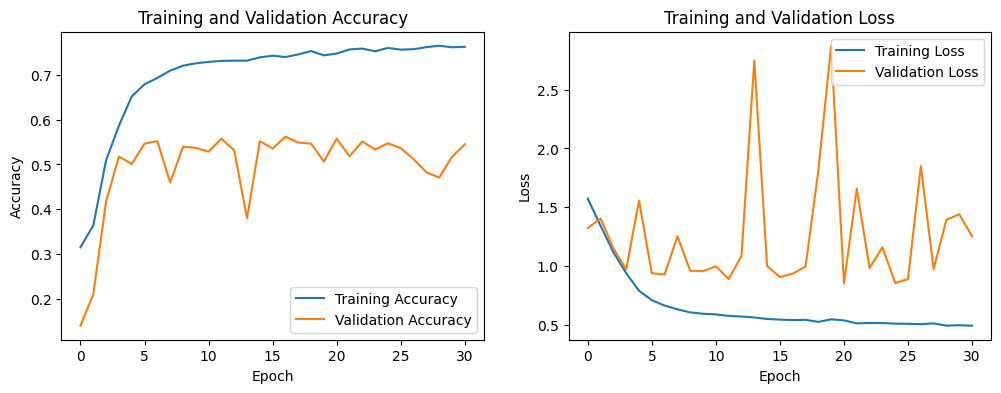

In [8]:
# Early Stopping 콜백 설정
# 성능이 안좋아질 때 학습을 멈추도록 만듦
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',     # 감시할 지표 (여기서는 오차값(loss) 감시)
        patience=10,            # 10번의 에폭 동안 개선이 없으면 학습 중단
        mode = 'min',           # 지표가 작아질수록 좋음 (max 를 쓸 경우, 커질수록 좋다는 의미)
        restore_best_weights=True,    #  가장 좋은 성능을 보였던 모델의 가중치(weights)를 복원
        verbose=1               # 중단 시 메시지 출력
    )
]
# 모델 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

# 학습 결과 시각화
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [9]:
# 모델 저장
model.save('./model/Alzheimer_model2.h5')
print("모델이 'Alzheimer_model2.h5'로 저장되었습니다.")
# 학습이 오래 걸릴 수 있으므로 파일로 저장하여 필요할 때 로드시키기

모델이 'Alzheimer_model2.h5'로 저장되었습니다.


In [10]:
# 저장된 모델 불러오기
from tensorflow.keras.models import load_model

model_path = './model/Alzheimer_model2.h5'  # 저장된 모델 경로
loaded_model = load_model(model_path)
print("저장된 모델이 성공적으로 로드되었습니다.")

# 저장된 모델을 활용한 이미지 예측 함수
def predict_flower_with_loaded_model(img_path, model, class_names):
    """
    이미지 경로와 모델을 입력받아 예측 결과를 출력하고 이미지를 시각화하는 함수.

    Parameters:
        img_path (str): 예측할 이미지 파일 경로.
        model (tf.keras.Model): 저장된 모델.
        class_names (list): 클래스 이름 리스트.
    """
    # 이미지 로드 및 전처리
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(img_height, img_width)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # 배치 차원 추가

    # 예측 수행
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # 예측 결과 출력
    print(
        "이 이미지는 '{}' ({:.2f}% 확률) 입니다."
        .format(class_names[np.argmax(score)], 100 * np.max(score))
    )

    # 이미지 시각화
    plt.imshow(img)
    plt.axis('off')
    plt.show()


저장된 모델이 성공적으로 로드되었습니다.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
이 이미지는 'Very Mild Impairment' (30.75% 확률) 입니다.


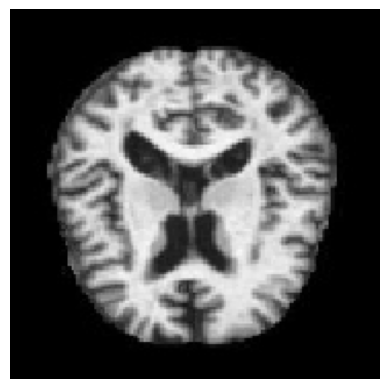

In [ ]:
# 테스트 이미지 경로
#test_image_path = './Combined Dataset/test/No Impairment/1 (77).jpg' # 맞춤 (37.77%)
#test_image_path = './Combined Dataset/test/No Impairment/26 (99).jpg' # 맞춤 (34.67%)
#test_image_path = './Combined Dataset/test/Very Mild Impairment/10 (52).jpg' # 맞춤 (34.19%)
#test_image_path = './Combined Dataset/test/Very Mild Impairment/11 (27).jpg' # 틀림 (No Impairment / 30.77%)
#test_image_path = './Combined Dataset/test/Mild Impairment/7 (4).jpg' # 틀림 (Very Mild Impairment / 35.26%)
#test_image_path = './Combined Dataset/test/Mild Impairment/15 (27).jpg' # 틀림 (No Impairment / 32.45%)
#test_image_path = './Combined Dataset/test/Moderate Impairment/17 (2).jpg' # 틀림 (Very Mild Impairment / 34.29%)
test_image_path = './Combined Dataset/test/Moderate Impairment/19.jpg' # 틀림 (Very Mild Impairment / 30.75%)
# 예측 실행
predict_flower_with_loaded_model(test_image_path, loaded_model, class_names)